In [13]:
# Exploratory Data Analysis (EDA)
# This notebook explores the rice leaf dataset used for disease classification.

import os
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [14]:
# Exploratory Data Analysis (EDA)
# This notebook explores the rice leaf dataset used for disease classification.

import os
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [15]:
import os
import pandas as pd

# Path to your dataset
base_path = "../data/raw/RiceLeafs"

data = []

# Loop through splits
for split in ["train", "validation"]:
    split_path = os.path.join(base_path, split)

    # Loop through each class folder
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)

        if os.path.isdir(label_path):
            # Loop through images
            for img in os.listdir(label_path):
                img_path = os.path.join(label_path, img)

                data.append({
                    "filepath": img_path,
                    "label": label,
                    "split": split
                })

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview
df.head()

,filepath,label,split
0,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
1,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
2,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
3,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
4,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train


In [16]:
df.head()

,filepath,label,split
0,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
1,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
2,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
3,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train
4,../data/raw/RiceLeafs\train\BrownSpot\IMG_2019...,BrownSpot,train


In [17]:
print("Columns:", df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Columns: ['filepath', 'label', 'split']

Missing values:

filepath    0
label       0
split       0
dtype: int64

Number of duplicate rows: 0


In [18]:
print("Columns:", df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Columns: ['filepath', 'label', 'split']

Missing values:

filepath    0
label       0
split       0
dtype: int64

Number of duplicate rows: 0


split
train         2684
validation     671
Name: count, dtype: int64


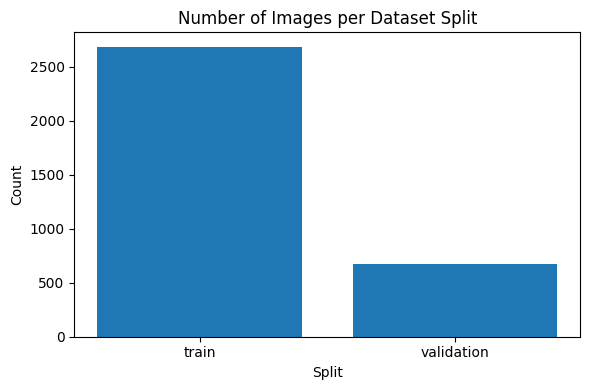

In [19]:
split_counts = df["split"].value_counts()
print(split_counts)

plt.figure(figsize=(6, 4))
plt.bar(split_counts.index, split_counts.values)
plt.title("Number of Images per Dataset Split")
plt.xlabel("Split")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Overall class distribution:

label
Healthy      1488
LeafBlast     779
Hispa         565
BrownSpot     523
Name: count, dtype: int64


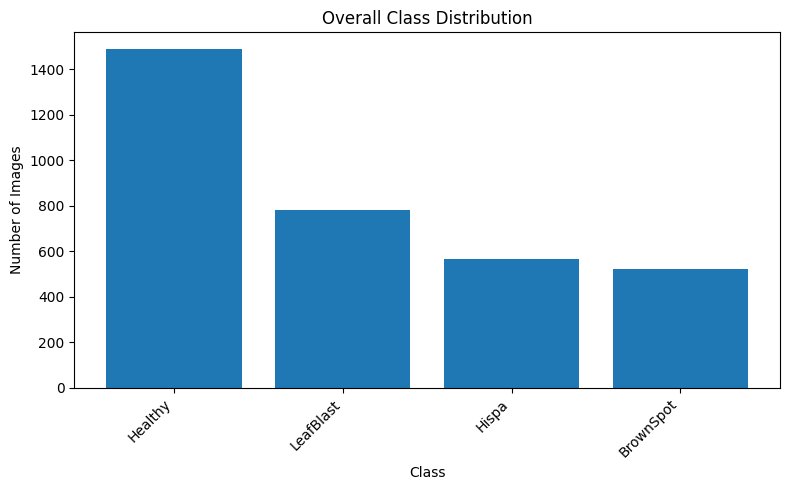

In [20]:
class_counts = df["label"].value_counts().sort_values(ascending=False)
print("Overall class distribution:\n")
print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Overall Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

split,train,validation
label,,
BrownSpot,418,105
Healthy,1191,297
Hispa,452,113
LeafBlast,623,156


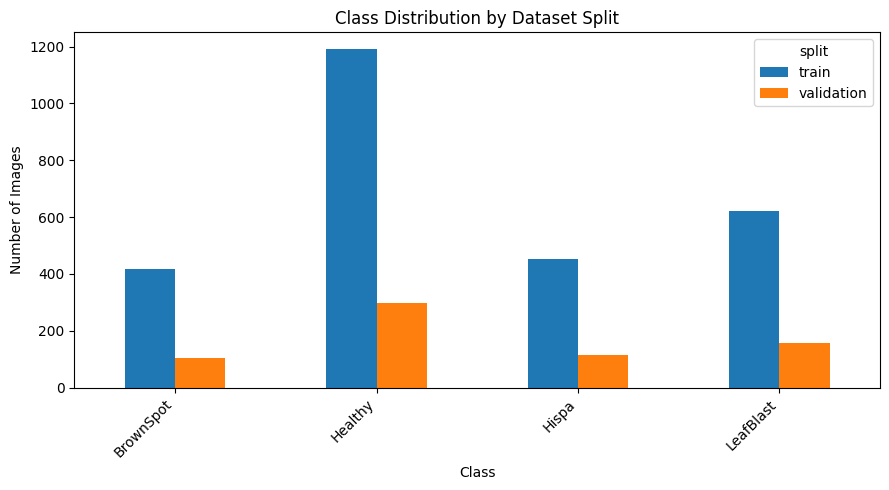

In [21]:
split_class_counts = pd.crosstab(df["label"], df["split"])
display(split_class_counts)

split_class_counts.plot(kind="bar", figsize=(9, 5))
plt.title("Class Distribution by Dataset Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

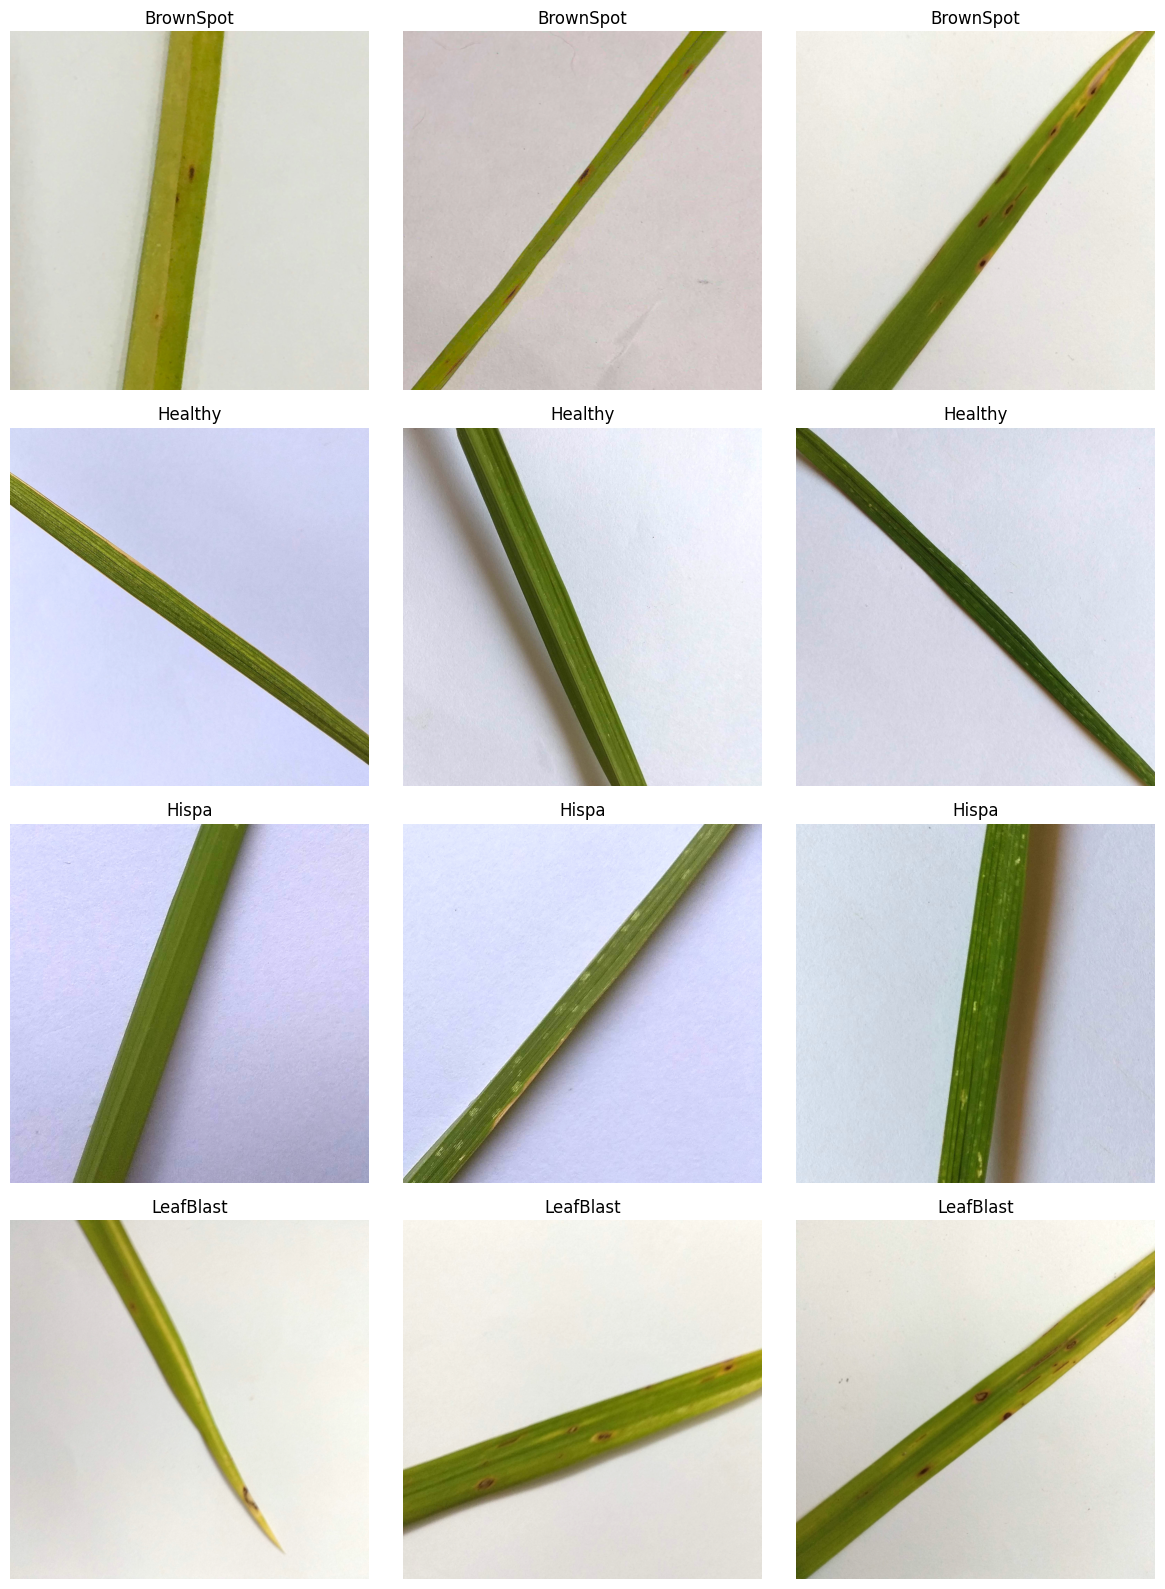

In [22]:
samples_per_class = 3
classes = sorted(df["label"].unique())

fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 4, len(classes) * 4))

if len(classes) == 1:
    axes = np.array([axes])

for row_idx, label in enumerate(classes):
    class_rows = df[df["label"] == label]
    sample_rows = class_rows.sample(n=min(samples_per_class, len(class_rows)), random_state=42)

    for col_idx in range(samples_per_class):
        ax = axes[row_idx, col_idx] if len(classes) > 1 else axes[col_idx]

        if col_idx < len(sample_rows):
            img_path = sample_rows.iloc[col_idx]["filepath"]
            try:
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(label)
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
        else:
            ax.text(0.5, 0.5, "No image", ha="center", va="center")

        ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
widths = []
heights = []
modes = []
bad_images = []

for path in df["filepath"]:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            modes.append(img.mode)
    except Exception as e:
        bad_images.append((path, str(e)))

print("Processed image files:", len(widths))
print("Unreadable image files:", len(bad_images))

Processed image files: 3355
Unreadable image files: 0


In [24]:
size_df = pd.DataFrame({
    "width": widths,
    "height": heights,
    "mode": modes
})

display(size_df.describe())
print("\nImage modes:\n")
print(size_df["mode"].value_counts())

,width,height
count,3355.000000,3355.000000
mean,2049.852757,2049.851565
std,607.889970,607.890651
min,734.000000,734.000000
25%,1604.500000,1604.500000
50%,1918.000000,1918.000000
75%,2363.000000,2363.000000
max,3120.000000,3120.000000



Image modes:

mode
RGB    3355
Name: count, dtype: int64


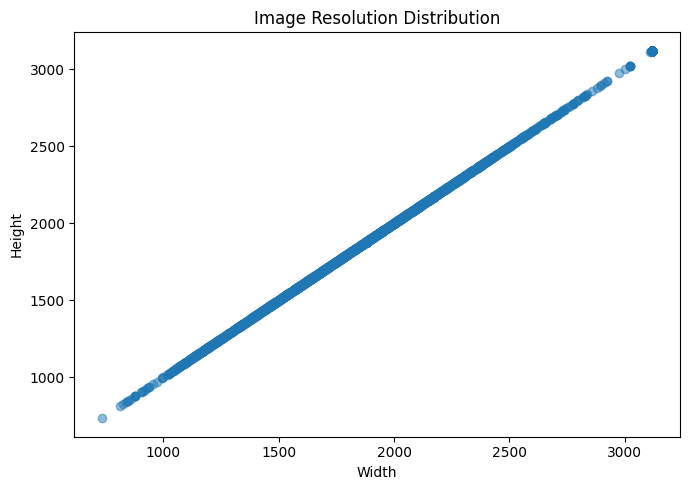

In [25]:
plt.figure(figsize=(7, 5))
plt.scatter(size_df["width"], size_df["height"], alpha=0.5)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

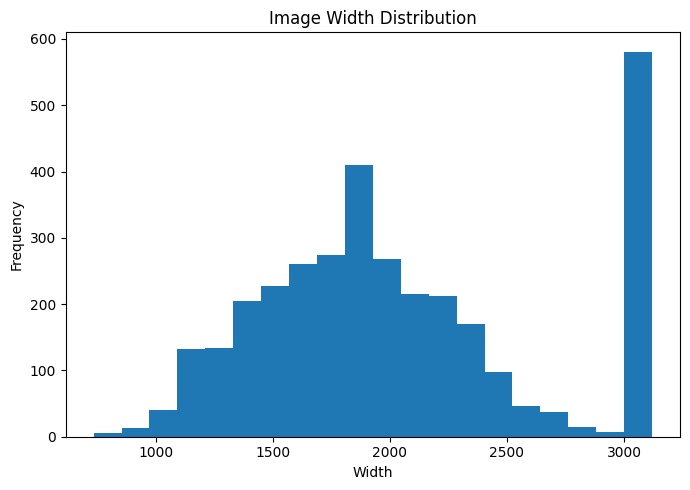

In [26]:
plt.figure(figsize=(7, 5))
plt.hist(size_df["width"], bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

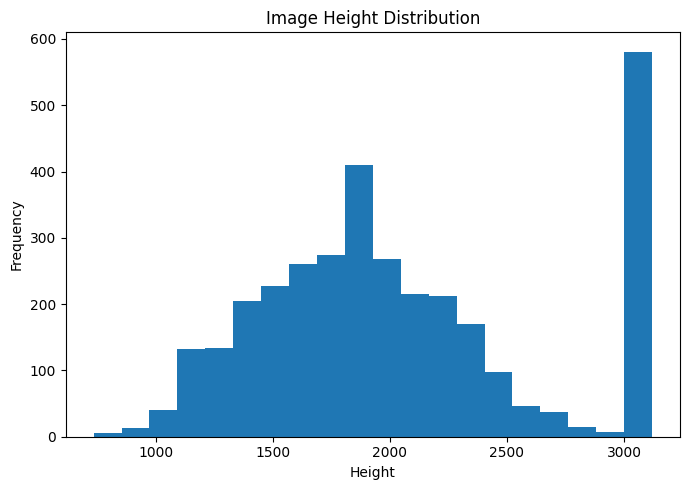

In [27]:
plt.figure(figsize=(7, 5))
plt.hist(size_df["height"], bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [28]:
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count if min_count > 0 else np.nan

print("Largest class size:", max_count)
print("Smallest class size:", min_count)
print("Imbalance ratio (largest / smallest):", round(imbalance_ratio, 2))

Largest class size: 1488
Smallest class size: 523
Imbalance ratio (largest / smallest): 2.85


In [29]:
# Observations
# - The dataset was successfully loaded from the train, validation, and test CSV files.
# - The class distribution plot shows how many images are available for each disease class and healthy leaves.
# - Sample images confirm visual differences among classes, although lighting, angle, and background may vary.
# - Image resolution analysis shows whether the original image sizes are consistent or varied, which supports resizing during preprocessing.
# - If one class has noticeably fewer images than others, macro-F1 score is important to evaluate balanced model performance across all classes.